# The kernel score, step by step

**Question:** does a model's simulated cloud look like the real cloud, *locally*?

Lower score is better. We compare 3 models on one real cloud.

In [1]:
import numpy as np, matplotlib.pyplot as plt
from scipy.spatial import cKDTree
from scipy.spatial.distance import cdist

rng = np.random.default_rng(0)
L, R, G, h = 15, 1.5, 21, 0.1   # window side, radius, grid size, blob width (units: mean spacing)

## 0. Data

Units are mean spacings, so the window has about $L^2$ points.
- **Real cloud:** clustered (Thomas, cluster sd 0.5).
- **Truth:** same process as the real cloud.
- **Wrong fit:** clusters too wide (sd 1.5).
- **CSR:** no structure.

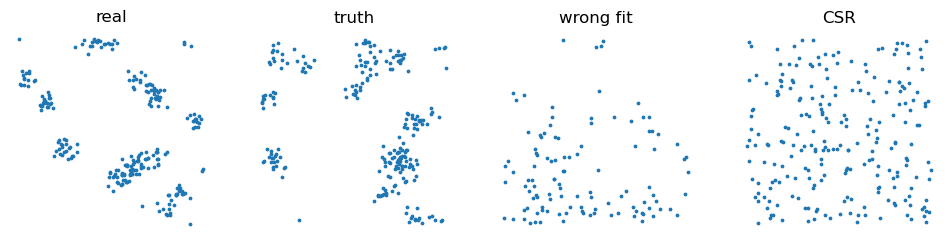

In [2]:
def thomas(s, mu=15):
    pad = 4 * s
    k = rng.poisson((L + 2 * pad) ** 2 / mu)
    kids = np.repeat(rng.uniform(-pad, L + pad, (k, 2)), rng.poisson(mu, k), axis=0)
    kids = kids + rng.normal(0, s, kids.shape)
    return kids[np.all((kids >= 0) & (kids <= L), axis=1)]

def csr():
    return rng.uniform(0, L, (rng.poisson(L * L), 2))

models = {"truth": lambda: thomas(0.5), "wrong fit": lambda: thomas(1.5), "CSR": csr}
x = thomas(0.5)   # the real cloud

fig, ax = plt.subplots(1, 4, figsize=(12, 3))
for a, (name, pts) in zip(ax, [("real", x)] + [(k, f()) for k, f in models.items()]):
    a.scatter(*pts.T, s=3); a.set_title(name); a.set_aspect("equal"); a.axis("off")

## 1. Snapshots

For a point, keep neighbours within $R$. Shift the point to the origin, divide by $R$.

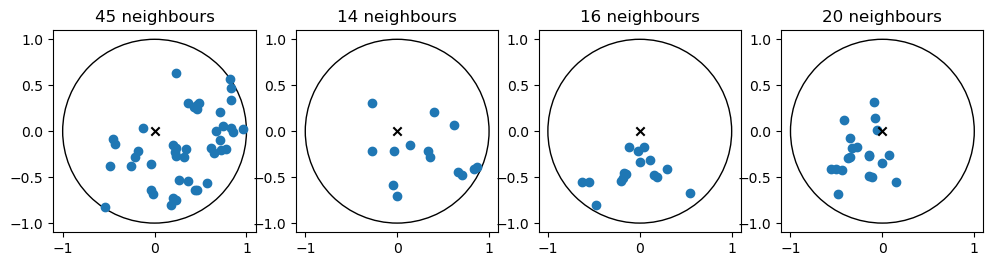

In [3]:
def snapshots(pts, max_c=300):
    """Local neighbourhoods around interior points (away from the edge)."""
    tree = cKDTree(pts)
    centres = np.flatnonzero(np.all((pts >= R) & (pts <= L - R), axis=1))
    centres = rng.choice(centres, min(max_c, len(centres)), replace=False)
    out = []
    for i, nb in zip(centres, tree.query_ball_point(pts[centres], R)):
        nb = [j for j in nb if j != i]
        out.append((pts[nb] - pts[i]) / R)
    return out

snaps = snapshots(x)
fig, ax = plt.subplots(1, 4, figsize=(12, 3))
for a, s in zip(ax, snaps):
    a.add_patch(plt.Circle((0, 0), 1, fill=False)); a.scatter(*s.T); a.scatter(0, 0, c="k", marker="x")
    a.set_xlim(-1.1, 1.1); a.set_ylim(-1.1, 1.1); a.set_aspect("equal"); a.set_title(f"{len(s)} neighbours")

## 2. Embedding

A snapshot has a variable number of points. Turn it into a fixed $21\times21$ image: one small blob per point.

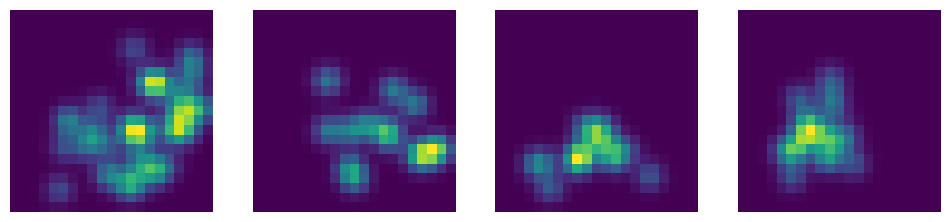

In [4]:
g = np.linspace(-1, 1, G)
nodes = np.stack(np.meshgrid(g, g), -1).reshape(-1, 2)

def embed(s):
    if len(s) == 0:
        return np.zeros(len(nodes))
    return np.exp(-cdist(nodes, s, "sqeuclidean") / (2 * h**2)).sum(1)

ex = np.array([embed(s) for s in snaps])   # real embeddings, shape (m, 441)
fig, ax = plt.subplots(1, 4, figsize=(12, 3))
for a, e in zip(ax, ex):
    a.imshow(e.reshape(G, G), origin="lower"); a.axis("off")

## 3. Distance and kernel

Distance = Euclidean distance between images.
Kernel = similarity: $k = \exp(-d^2 / 2\tau^2)$, so 1 if identical and near 0 if far.

$\tau$ is the **median distance between the real snapshots**. Fixed once, reused for every model.

In [5]:
d = cdist(ex, ex)
tau = np.median(d[np.triu_indices(len(d), 1)])
kernel = lambda dist: np.exp(-dist**2 / (2 * tau**2))

print(f"tau = {tau:.2f}")
print("k at d = 0, tau, 2 tau, 3 tau:", kernel(np.array([0, tau, 2 * tau, 3 * tau])).round(3))

tau = 18.48
k at d = 0, tau, 2 tau, 3 tau: [1.    0.607 0.135 0.011]


## 4. The score

$$S = \tfrac12\,A - B$$

- **B** = average similarity between real snapshots and model snapshots. High is good.
- **A** = average similarity between two model snapshots from *different* simulations. High means the model repeats itself, which is bad.

Simulate 16 clouds per model.

In [6]:
def score(make, n_sims=16):
    embs = [np.array([embed(s) for s in snapshots(make(), max_c=100)]) for _ in range(n_sims)]
    which = np.concatenate([np.full(len(e), i) for i, e in enumerate(embs)])
    E = np.concatenate(embs)
    B = kernel(cdist(ex, E)).mean()
    A = kernel(cdist(E, E))[which[:, None] != which[None, :]].mean()
    return dict(A=A, B=B, S=0.5 * A - B)

res = {name: score(f) for name, f in models.items()}
print(f"{'model':<10}{'A':>8}{'B':>8}{'S':>9}")
for name, r in res.items():
    print(f"{name:<10}{r['A']:>8.3f}{r['B']:>8.3f}{r['S']:>9.3f}")

model            A       B        S
truth        0.731   0.657   -0.292
wrong fit    0.907   0.687   -0.233
CSR          0.938   0.685   -0.216


Lower $S$ is better. The truth should win and CSR should lose.

## 5. Regret, gain, skill

- **regret** = S(fit) − S(truth): how much worse than the truth.
- **gain** = S(CSR) − S(truth): how much the truth beats CSR.
- **skill** = 1 − regret / gain: 1 is as good as the truth, 0 is no better than CSR.

In [7]:
S = {k: r["S"] for k, r in res.items()}
regret = S["wrong fit"] - S["truth"]
gain = S["CSR"] - S["truth"]
print(f"regret = {regret:.3f}   gain = {gain:.3f}   skill = {1 - regret / gain:.2f}")

regret = 0.059   gain = 0.076   skill = 0.22
